In [2]:
import pandas as pd 

1. Quality filtering (optional but recommended)

2. Missing value imputation (after filtering)

3. Normalization (use QC-based )

4. Batch effect correction (e.g., ComBat)

   ComBat assumes normalized input


In [3]:
file_path = r"C:\project8  Robotics and AI enable automation in modern proteomics\files"
figure_path = r"C:\project8  Robotics and AI enable automation in modern proteomics\figures"

In [4]:
# check batch effect 

In [5]:
df_filter = pd.read_csv(f'{file_path}\drug_names_replaced_filtered_raw.csv', index_col = 0)
df_filter

,Blue1_A10_QC,Blue1_A11_QC,Blue1_A12_QC,Blue1_A1_QC,Blue1_A2_QC,Blue1_A3_QC,Blue1_A4_QC,Blue1_A5_QC,Blue1_A6_QC,Blue1_A7_QC,...,Redmix_G11_QC,Redmix_G1_QC,Redmix_G2_QC,Redmix_G3_QC,Redmix_G4_QC,Redmix_G5_QC,Redmix_G6_QC,Redmix_G7_QC,Redmix_G8_QC,Redmix_G9_QC
protein,,,,,,,,,,,,,,,,,,,,,
SMIM26,370638.0,418362.0,367084.00,272169.0,223697.0,270338.0,271311.0,314088.0,214471.0,324792.0,...,212573.00,314754.0,266553.0,364660.0,416568.0,326285.0,229478.0,209105.00,549889.00,326546.0
MSANTD7,20843.0,14109.7,8611.23,21220.8,NaN,NaN,21491.2,12171.9,21276.7,15871.0,...,9266.69,23699.3,18722.8,19174.3,11511.2,10270.4,10605.4,6231.03,9639.03,14868.0
CAST,15874300.0,16455400.0,16994800.00,17979800.0,18439800.0,16483900.0,17987500.0,16106000.0,17086600.0,17413000.0,...,19612800.00,20306900.0,18606800.0,20460000.0,21279900.0,20207400.0,21750300.0,21564200.00,20029500.00,20454300.0
GNG5B,NaN,54376.9,63602.30,321535.0,165091.0,106020.0,124390.0,55749.1,56498.5,NaN,...,263655.00,251610.0,191740.0,223754.0,283729.0,307757.0,277370.0,307495.00,185277.00,198248.0
NKRF,3753250.0,3820310.0,3547970.00,3505860.0,3922710.0,3356580.0,3768140.0,3205860.0,3842290.0,4078990.0,...,4306300.00,3815300.0,3868550.0,4156880.0,4065890.0,3492930.0,4072120.0,3949970.00,3937060.00,4294380.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FAM169A,16131000.0,16721100.0,17064200.00,20370300.0,20045300.0,17150100.0,17588000.0,18539300.0,18880800.0,17605200.0,...,19887800.00,21562500.0,17344000.0,20698200.0,20868300.0,20229000.0,21823700.0,21312700.00,21853100.00,20084900.0
ZHX2,1999080.0,2031080.0,2383520.00,2165690.0,2197560.0,2030700.0,2157100.0,2145110.0,2181390.0,2001110.0,...,2761870.00,2946840.0,2631390.0,2726330.0,2867600.0,2884210.0,3000970.0,3225140.00,2642480.00,2980350.0
MORC2,3978720.0,3859560.0,3839220.00,4678720.0,4472290.0,3969780.0,3971150.0,4090160.0,3948360.0,4027260.0,...,5094570.00,5330130.0,4951470.0,5355340.0,5225840.0,5602700.0,5332710.0,5830990.00,5411980.00,5255010.0


In [6]:
design_map = pd.read_csv(f'{file_path}\drug_map.csv')
design_map

,Unnamed: 0,Plate Color,Plate Number,Well,Aliqout Type,ProductName,Synonyms,CAS Number,M.Wt,Target,...,URL,Research Area,Clinical Information,BaseName,Priority,SearchText,Category,Unnamed: 25,wellnames,drugnames
0,0,Red,1,A1,QC,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Red1_A1,Red1_A1_QC
1,1,Red,1,A2,QC,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Red1_A2,Red1_A2_QC
2,2,Red,1,A3,QC,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Red1_A3,Red1_A3_QC
3,3,Red,1,A4,QC,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Red1_A4,Red1_A4_QC
4,4,Red,1,A5,QC,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Red1_A5,Red1_A5_QC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1231,1231,Redmix,mix,G8,QC,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Redmix_G8,Redmix_G8_QC
1232,1232,Redmix,mix,G9,QC,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Redmix_G9,Redmix_G9_QC
1233,1233,Redmix,mix,G10,QC,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Redmix_G10,Redmix_G10_QC
1234,1234,Redmix,mix,G11,QC,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Redmix_G11,Redmix_G11_QC


In [7]:
map_drug_to_well = dict(zip(design_map["drugnames"], design_map["wellnames"]))
map_well_to_drug = dict(zip(design_map["wellnames"], design_map["drugnames"]))

In [8]:
df_filter_wellnames = df_filter.rename(columns = map_drug_to_well)
df_filter_wellnames

,Blue1_A10,Blue1_A11,Blue1_A12,Blue1_A1,Blue1_A2,Blue1_A3,Blue1_A4,Blue1_A5,Blue1_A6,Blue1_A7,...,Redmix_G11,Redmix_G1,Redmix_G2,Redmix_G3,Redmix_G4,Redmix_G5,Redmix_G6,Redmix_G7,Redmix_G8,Redmix_G9
protein,,,,,,,,,,,,,,,,,,,,,
SMIM26,370638.0,418362.0,367084.00,272169.0,223697.0,270338.0,271311.0,314088.0,214471.0,324792.0,...,212573.00,314754.0,266553.0,364660.0,416568.0,326285.0,229478.0,209105.00,549889.00,326546.0
MSANTD7,20843.0,14109.7,8611.23,21220.8,NaN,NaN,21491.2,12171.9,21276.7,15871.0,...,9266.69,23699.3,18722.8,19174.3,11511.2,10270.4,10605.4,6231.03,9639.03,14868.0
CAST,15874300.0,16455400.0,16994800.00,17979800.0,18439800.0,16483900.0,17987500.0,16106000.0,17086600.0,17413000.0,...,19612800.00,20306900.0,18606800.0,20460000.0,21279900.0,20207400.0,21750300.0,21564200.00,20029500.00,20454300.0
GNG5B,NaN,54376.9,63602.30,321535.0,165091.0,106020.0,124390.0,55749.1,56498.5,NaN,...,263655.00,251610.0,191740.0,223754.0,283729.0,307757.0,277370.0,307495.00,185277.00,198248.0
NKRF,3753250.0,3820310.0,3547970.00,3505860.0,3922710.0,3356580.0,3768140.0,3205860.0,3842290.0,4078990.0,...,4306300.00,3815300.0,3868550.0,4156880.0,4065890.0,3492930.0,4072120.0,3949970.00,3937060.00,4294380.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FAM169A,16131000.0,16721100.0,17064200.00,20370300.0,20045300.0,17150100.0,17588000.0,18539300.0,18880800.0,17605200.0,...,19887800.00,21562500.0,17344000.0,20698200.0,20868300.0,20229000.0,21823700.0,21312700.00,21853100.00,20084900.0
ZHX2,1999080.0,2031080.0,2383520.00,2165690.0,2197560.0,2030700.0,2157100.0,2145110.0,2181390.0,2001110.0,...,2761870.00,2946840.0,2631390.0,2726330.0,2867600.0,2884210.0,3000970.0,3225140.00,2642480.00,2980350.0
MORC2,3978720.0,3859560.0,3839220.00,4678720.0,4472290.0,3969780.0,3971150.0,4090160.0,3948360.0,4027260.0,...,5094570.00,5330130.0,4951470.0,5355340.0,5225840.0,5602700.0,5332710.0,5830990.00,5411980.00,5255010.0


In [8]:
# df_filter_wellnames.columns[:100]

# missing value imputation 

In [9]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import seaborn as sns

C:\Users\jiangy5\AppData\Roaming\Python\Python39\site-packages\matplotlib\projections\__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


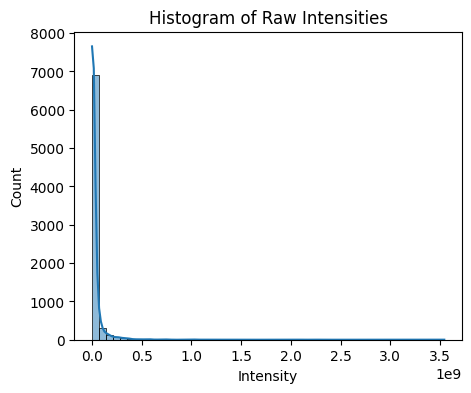

data right skewed


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sample = df_filter.iloc[:, 0]  # 第1个样本

plt.figure(figsize=(5,4))
sns.histplot(sample.dropna(), kde=True, bins=50)
plt.title("Histogram of Raw Intensities")
plt.xlabel("Intensity")
plt.show()
print("data right skewed")

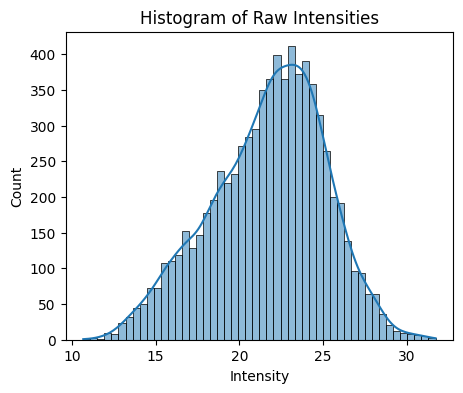

data normal distributed


In [11]:
# log2 Transfer 

df_log2 = np.log2(df_filter_wellnames + 1)
plt.figure(figsize=(5,4))
sns.histplot(df_log2.iloc[:, 0].dropna(), kde=True, bins=50)
plt.title("Histogram of Raw Intensities")
plt.xlabel("Intensity")
plt.show()
print("data normal distributed")

In [12]:

# -----------------------------------------
# 1. df_filter is the filtered dataset
# rows = proteins, columns = samples
# -----------------------------------------

df_impute = df_log2.copy()

# KNNImputer setup
# n_neighbors=5 is standard for proteomics
imputer = KNNImputer(
    n_neighbors=5,
    weights="distance"  # closer neighbors get higher weight
)

# -----------------------------------------
# 2. Fit & transform
# -----------------------------------------
df_imputed_array = imputer.fit_transform(df_impute)

# Convert back to DataFrame
df_imputed = pd.DataFrame(
    df_imputed_array,
    index=df_impute.index,
    columns=df_impute.columns
)

print("KNN imputation completed!")
df_imputed.head()


KNN imputation completed!


,Blue1_A10,Blue1_A11,Blue1_A12,Blue1_A1,Blue1_A2,Blue1_A3,Blue1_A4,Blue1_A5,Blue1_A6,Blue1_A7,...,Redmix_G11,Redmix_G1,Redmix_G2,Redmix_G3,Redmix_G4,Redmix_G5,Redmix_G6,Redmix_G7,Redmix_G8,Redmix_G9
protein,,,,,,,,,,,,,,,,,,,,,
SMIM26,18.499655,18.674396,18.485755,18.054149,17.771193,18.044410,18.049593,18.260814,17.710430,18.309161,...,17.697606,18.263870,18.024068,18.476196,18.668196,18.315778,17.808003,17.673875,19.068784,18.316931
MSANTD7,14.347345,13.784502,13.072171,14.373259,14.039701,14.306599,14.391526,13.571385,14.377055,13.954196,...,13.177994,14.532618,14.192586,14.226962,13.490876,13.326345,13.372647,12.605486,13.234822,13.860020
CAST,23.920190,23.972058,24.018590,24.099874,24.136320,23.974554,24.100491,23.941095,24.026362,24.053662,...,24.225292,24.275467,24.149327,24.286303,24.342988,24.268380,24.374532,24.362135,24.255623,24.285901
GNG5B,16.873672,15.730733,15.956814,18.294621,17.332911,16.693991,16.924523,15.766687,15.785950,16.937504,...,18.008297,17.940835,17.548799,17.771560,18.114159,18.231437,18.081457,18.230208,17.499332,17.596954
NKRF,21.839709,21.865259,21.758563,21.741337,21.903420,21.678561,21.845422,21.612280,21.873535,21.959781,...,22.038018,21.863365,21.883362,21.987070,21.955140,21.736007,21.957349,21.913411,21.908688,22.034019


In [13]:
df_imputed.to_csv(f'{file_path}\log_imputed_well_names.csv')

# Normalization with QCs

In [14]:
df2 = df_imputed.rename(columns = map_well_to_drug).copy()

qc_cols = [c for c in df2.columns if "_QC" in c]
sample_cols = [c for c in df2.columns if c not in qc_cols]

print("QC samples:", len(qc_cols))
print("Sample samples:", len(sample_cols))


QC samples: 155
Sample samples: 1055


In [15]:
inj_clean = pd.read_csv(f'{file_path}\injection order.csv', index_col = 0 )
# inj_clean

In [16]:
# 假设你的 injection order 叫 inj_clean，并且有 'LastWriteTime' 和 'base' 两列
inj_clean['LastWriteTime'] = pd.to_datetime(inj_clean['LastWriteTime'])

inj_sorted = (
    inj_clean
    .sort_values('LastWriteTime')
    .reset_index(drop=True)
)

# 这是按注射顺序排好的样本名
inj_order = inj_sorted['base'].tolist()
len(inj_order)

1235

In [17]:
# 先取出“既在 injection order 中、又在 df_imputed 中”的列
cols_in_both = [c for c in inj_order if c in df_imputed.columns]

# 再把 df_imputed 中剩下的列放在后面（比如某些 QC、统计列等）
other_cols = [c for c in df_imputed.columns if c not in cols_in_both]
print(other_cols)

# 组合成新的列顺序
new_col_order = cols_in_both + other_cols

# 按新顺序重排
df_imputed_ordered = df_imputed[new_col_order].copy()
df_imputed_ordered

[]


,Blue1_B1,Blue1_C2,Blue1_C3,Blue1_C8,Blue1_E10,Blue1_H1,Blue1_E9,Blue1_D7,Blue1_B4,Blue1_A1,...,Redmix_D2,Redmix_D10,Redmix_B6,Redmix_C10,Redmix_G7,Redmix_A2,Redmix_E9,Redmix_B11,Redmix_F11,Redmix_C7
protein,,,,,,,,,,,,,,,,,,,,,
SMIM26,19.959135,19.284422,19.586411,19.851595,19.592908,17.505494,18.679285,18.342335,19.432336,18.054149,...,19.989166,18.845744,18.532679,18.879811,17.673875,19.645986,19.373424,18.867086,18.920286,19.203668
MSANTD7,13.581542,12.668652,14.455147,13.156685,13.979515,13.349102,13.472845,14.297112,14.592334,14.373259,...,13.811385,12.853920,13.599971,14.173544,12.605486,13.705136,13.890673,12.524432,13.387115,13.141419
CAST,24.145429,24.243987,24.221838,24.219322,24.103360,24.992628,24.164460,24.006048,24.245330,24.099874,...,24.478827,24.224534,24.185460,24.255940,24.362135,24.287501,24.147698,24.078818,24.165357,24.206665
GNG5B,17.335731,17.151443,16.113767,17.187197,16.720663,18.959594,18.483257,17.048200,16.945089,18.294621,...,18.310573,17.863206,17.515299,18.506614,18.230208,16.957181,17.699735,17.547196,16.899499,18.143313
NKRF,22.116754,22.237431,22.171300,22.184681,22.151236,22.436687,22.215085,22.395489,22.101058,21.741337,...,22.071500,22.246399,22.139624,22.338443,21.913411,21.906884,22.022656,21.980464,22.090643,22.108686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FAM169A,24.371225,24.166453,23.915857,24.062944,23.949197,24.627952,24.425831,24.711548,24.347348,24.279964,...,24.378949,24.047243,24.193385,24.052476,24.345210,24.420726,23.938827,24.027746,24.031377,24.063158
ZHX2,20.710451,20.758624,20.762636,20.613855,20.771827,21.417738,19.893493,20.504808,20.554172,21.046396,...,21.027500,20.673196,21.075798,20.556035,21.620931,21.056056,20.973849,21.051729,21.117753,20.914641
MORC2,21.999834,22.140305,22.041631,21.952085,21.856942,22.352296,22.043695,22.358435,21.787953,22.157683,...,22.181421,22.013031,22.200557,21.975452,22.475310,22.035120,22.103919,22.153257,22.202020,22.179032


In [18]:
df_imputed_ordered.to_csv(f'{file_path}\log_imputed_well_names_OrderedByTime.csv')

In [19]:
df_imputed_ordered_drugnames = df_imputed_ordered.rename(columns = map_well_to_drug)
df_imputed_ordered_drugnames

,Caroverine (hydrochloride)_1,Tucatinib_1,Chloroprocaine (hydrochloride)_1,Liarozole_1,Aniracetam_1,Blue1_H1_DFO,Digitoxin_1,Clomiphene (citrate)_1,Betamethasone disodium phosphate_1,Blue1_A1_QC,...,Liranaftate_4,Cabazitaxel_4,Azelastine (hydrochloride)_2,Cabazitaxel_3,Redmix_G7_QC,Liranaftate_1,Paritaprevir_5,Latrepirdine (dihydrochloride)_2,Latrepirdine (dihydrochloride)_6,Cobicistat_3
protein,,,,,,,,,,,,,,,,,,,,,
SMIM26,19.959135,19.284422,19.586411,19.851595,19.592908,17.505494,18.679285,18.342335,19.432336,18.054149,...,19.989166,18.845744,18.532679,18.879811,17.673875,19.645986,19.373424,18.867086,18.920286,19.203668
MSANTD7,13.581542,12.668652,14.455147,13.156685,13.979515,13.349102,13.472845,14.297112,14.592334,14.373259,...,13.811385,12.853920,13.599971,14.173544,12.605486,13.705136,13.890673,12.524432,13.387115,13.141419
CAST,24.145429,24.243987,24.221838,24.219322,24.103360,24.992628,24.164460,24.006048,24.245330,24.099874,...,24.478827,24.224534,24.185460,24.255940,24.362135,24.287501,24.147698,24.078818,24.165357,24.206665
GNG5B,17.335731,17.151443,16.113767,17.187197,16.720663,18.959594,18.483257,17.048200,16.945089,18.294621,...,18.310573,17.863206,17.515299,18.506614,18.230208,16.957181,17.699735,17.547196,16.899499,18.143313
NKRF,22.116754,22.237431,22.171300,22.184681,22.151236,22.436687,22.215085,22.395489,22.101058,21.741337,...,22.071500,22.246399,22.139624,22.338443,21.913411,21.906884,22.022656,21.980464,22.090643,22.108686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FAM169A,24.371225,24.166453,23.915857,24.062944,23.949197,24.627952,24.425831,24.711548,24.347348,24.279964,...,24.378949,24.047243,24.193385,24.052476,24.345210,24.420726,23.938827,24.027746,24.031377,24.063158
ZHX2,20.710451,20.758624,20.762636,20.613855,20.771827,21.417738,19.893493,20.504808,20.554172,21.046396,...,21.027500,20.673196,21.075798,20.556035,21.620931,21.056056,20.973849,21.051729,21.117753,20.914641
MORC2,21.999834,22.140305,22.041631,21.952085,21.856942,22.352296,22.043695,22.358435,21.787953,22.157683,...,22.181421,22.013031,22.200557,21.975452,22.475310,22.035120,22.103919,22.153257,22.202020,22.179032


In [20]:
df_imputed_ordered_drugnames.columns[-50:]

Index(['Ambroxol_2', 'Pergolide (mesylate)_6', 'Efavirenz_1', 'Cobicistat_1',
       'Redmix_G2_QC', 'Latrepirdine (dihydrochloride)_3', 'Remdesivir_2',
       'Pergolide (mesylate)_1', 'Efavirenz_4', 'Oteseconazole_1',
       'Cobicistat_5', 'Azelastine (hydrochloride)_4', 'Redmix_G6_QC',
       'Pergolide (mesylate)_4', 'Oteseconazole_5', 'Paritaprevir_3',
       'Liranaftate_2', 'Cabazitaxel_6', 'Pergolide (mesylate)_2',
       'Paritaprevir_2', 'Redmix_G11_QC', 'Ambroxol_6', 'Paritaprevir_4',
       'Pergolide (mesylate)_3', 'Remdesivir_6', 'Paritaprevir_6',
       'Cobicistat_2', 'Ambroxol_3', 'Redmix_G10_QC',
       'Azelastine (hydrochloride)_1', 'Saquinavir (mesylate)_3',
       'Latrepirdine (dihydrochloride)_1', 'Saquinavir (mesylate)_6',
       'Efavirenz_5', 'Latrepirdine (dihydrochloride)_5', 'Oteseconazole_4',
       'Redmix_G9_QC', 'Cobicistat_4', 'Azelastine (hydrochloride)_6',
       'Efavirenz_2', 'Liranaftate_4', 'Cabazitaxel_4',
       'Azelastine (hydrochloride)_2'

In [21]:

from statsmodels.nonparametric.smoothers_lowess import lowess

def qc_loess_normalization(
    df: pd.DataFrame,
    qc_keyword: str = "_QC",
    frac: float = 0.3,
) -> pd.DataFrame:
    """
    Perform QC-based LOESS normalization on a proteomic data matrix.

    Parameters
    ----------
    df : pd.DataFrame
        Quantitative matrix, rows = features (proteins), columns = samples.
        Columns are already ordered by injection sequence.
    qc_keyword : str, default "_QC"
        Substring used to identify QC samples in column names.
    frac : float, default 0.3
        Fraction of data used in each LOESS local regression.
        Larger values -> smoother curve.

    Returns
    -------
    df_norm : pd.DataFrame
        LOESS-normalized data matrix with the same shape as input.
    """

    df = df.copy()

    # -----------------------------
    # 1. Identify QC and sample columns
    # -----------------------------
    qc_cols = [c for c in df.columns if qc_keyword in c]
    if len(qc_cols) < 3:
        raise ValueError("Not enough QC samples for LOESS (need >= 3).")

    sample_cols = [c for c in df.columns if c not in qc_cols]

    # Positions (indices) of QC injections in the whole run (0-based)
    qc_positions = np.array([df.columns.get_loc(c) for c in qc_cols])

    # Pre-compute, for each sample column, the index of the nearest QC
    nearest_qc_idx_for_sample = {}
    for col in sample_cols:
        pos = df.columns.get_loc(col)
        # index in qc_positions array
        idx = int(np.argmin(np.abs(qc_positions - pos)))
        nearest_qc_idx_for_sample[col] = idx

    # Result container
    df_norm = df.copy()

    # -----------------------------
    # 2. Loop over features (rows) and apply LOESS on QC intensities
    # -----------------------------
    for feature in df.index:
        # QC values for this feature (1D numpy array)
        y = df.loc[feature, qc_cols].values.astype(float)

        # Skip features with too many missing values in QC
        if np.all(np.isnan(y)):
            # leave this feature unchanged
            continue

        # For safety, fill remaining NaNs in QC values with their median
        # (or you can choose mean; here we use median)
        if np.any(np.isnan(y)):
            median_y = np.nanmedian(y)
            y = np.where(np.isnan(y), median_y, y)

        x = qc_positions.astype(float)

        # LOESS smoothing on QC values along injection order
        fitted = lowess(
            endog=y,
            exog=x,
            frac=frac,
            return_sorted=False
        )

        # Normalize the LOESS curve to its median level
        # -> this gives us a multiplicative drift profile
        curve_median = np.median(fitted)
        if curve_median == 0:
            # avoid division by zero; skip this feature
            continue

        correction_factors = fitted / curve_median  # shape: (n_QC,)

        # -----------------------------
        # 3. Apply correction to QC columns
        # -----------------------------
        for i, qc_col in enumerate(qc_cols):
            df_norm.loc[feature, qc_col] = (
                df.loc[feature, qc_col] / correction_factors[i]
            )

        # -----------------------------
        # 4. Apply correction to non-QC samples
        #    Using correction factor of the nearest QC
        # -----------------------------
        for col in sample_cols:
            qc_idx = nearest_qc_idx_for_sample[col]
            factor = correction_factors[qc_idx]
            df_norm.loc[feature, col] = df.loc[feature, col] / factor

    return df_norm




In [22]:
# ------------------------------------------------------
# Example usage on matrix: df_imputed_ordered_drugnames
# ------------------------------------------------------
df_norm_loess = qc_loess_normalization(
    df_imputed_ordered_drugnames,
    qc_keyword="_QC",   # QC samples contain "_QC" in column names
    frac=0.3            # you can tune this (0.2–0.4 is common)
)




In [24]:
df_norm_loess.rename(columns = map_drug_to_well).to_csv(f'{file_path}\log_imputed_normalized_OrderedByTime_wellnames.csv')

In [27]:
# df_norm_loess.rename(columns = map_drug_to_well)

In [26]:

df_norm_loess.to_csv(f'{file_path}\log_imputed_normalized_OrderedByTime_drugnames.csv')

In [45]:
df_norm_loess

,Caroverine (hydrochloride)_1,Tucatinib_1,Chloroprocaine (hydrochloride)_1,Liarozole_1,Aniracetam_1,Blue1_H1_DFO,Digitoxin_1,Clomiphene (citrate)_1,Betamethasone disodium phosphate_1,Blue1_A1_QC,...,Liranaftate_4,Cabazitaxel_4,Azelastine (hydrochloride)_2,Cabazitaxel_3,Redmix_G7_QC,Liranaftate_1,Paritaprevir_5,Latrepirdine (dihydrochloride)_2,Latrepirdine (dihydrochloride)_6,Cobicistat_3
protein,,,,,,,,,,,,,,,,,,,,,
SMIM26,19.977340,19.302012,19.604277,19.869702,19.610779,17.521461,18.696323,18.359066,19.450061,18.070616,...,19.916016,18.785901,18.473830,18.819859,17.617753,19.583601,19.311905,18.807174,18.860206,19.142688
MSANTD7,13.418656,12.516715,14.281784,12.998894,13.811855,13.189003,13.311263,14.125644,14.417326,14.200878,...,14.314633,13.348875,14.123654,14.719314,13.090876,14.232868,14.425550,13.006700,13.902602,13.647445
CAST,24.196157,24.294922,24.272726,24.270205,24.153999,25.045135,24.215227,24.056483,24.296267,24.150506,...,24.284664,24.023157,23.984407,24.054301,24.159613,24.085600,23.946959,23.878652,23.964471,24.005436
GNG5B,17.620371,17.433058,16.378344,17.469399,16.995204,19.270898,18.786739,17.328120,17.223316,18.595006,...,17.085268,16.619524,16.295840,17.218136,16.960974,15.776579,16.467434,16.325515,15.722912,16.880130
NKRF,22.130976,22.251732,22.185558,22.198947,22.165481,22.451116,22.229371,22.409892,22.115271,21.755319,...,21.988951,22.159334,22.052977,22.251018,21.827649,21.821147,21.936467,21.894440,22.004187,22.022160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FAM169A,24.437691,24.232360,23.981081,24.128569,24.014511,24.695118,24.492445,24.778942,24.413748,24.346181,...,24.190580,23.852800,23.997761,23.857992,24.148358,24.223264,23.745261,23.833461,23.837063,23.868587
ZHX2,20.774057,20.822379,20.826403,20.677165,20.835622,21.483516,19.954590,20.567783,20.617298,21.111034,...,20.666508,20.306121,20.701575,20.191041,21.237028,20.682183,20.601436,20.677932,20.742784,20.543279
MORC2,22.077501,22.218468,22.119446,22.029584,21.934104,22.431208,22.121517,22.437368,21.864872,22.235907,...,21.853098,21.672467,21.857091,21.635469,22.127593,21.694214,21.761948,21.810523,21.858532,21.835899


QC 样本数: 155


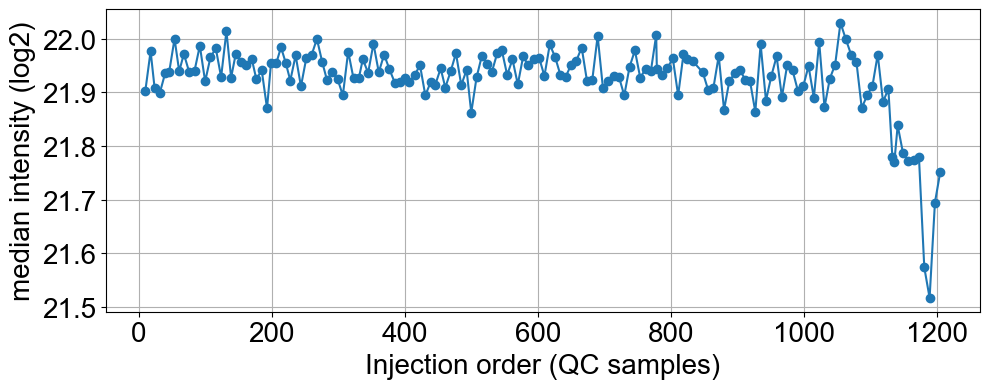

In [33]:


# 这里用你已经按 injection 顺序排好的矩阵
dfdf = df_imputed_ordered_drugnames.copy()

# 1. 找出 QC 列
qc_cols = [c for c in dfdf.columns if "_QC" in c]
print("QC 样本数:", len(qc_cols))

# 2. 每个 QC 在整个 injection 序列中的位置（列索引，从 1 开始）
qc_positions = np.array([dfdf.columns.get_loc(c) + 1 for c in qc_cols])

# 3. 计算每针 QC 的整体强度（你是 log2 强度的话，用 median/mean 都可以）
#    这里用每个 QC 样本在所有蛋白上的中位数
qc_intensity = dfdf[qc_cols].median(axis=0).values    # shape = (n_QC,)

# 4. 画 QC drift 曲线
plt.figure(figsize=(10, 4))
plt.rcParams["font.family"] = "Arial" 
plt.plot(qc_positions, qc_intensity, marker="o")
plt.xlabel("Injection order (QC samples)", fontsize = 20)
plt.ylabel("median intensity (log2)", fontsize = 20)
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
# plt.title("QC drift curve (before normalization)")
plt.grid(True)
plt.tight_layout()
plt.savefig(f'{figure_path}\QC drift with time_after normalize.svg', dpi=800)
plt.show()


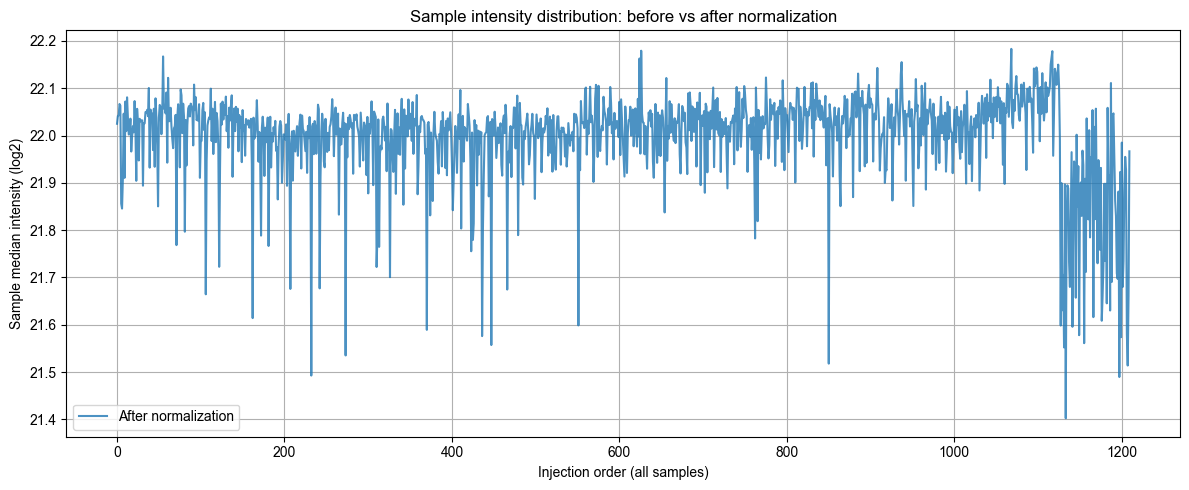

In [30]:


# df_before = df_imputed_ordered_drugnames
# df_after  = df_norm_loess  (from your LOESS normalization)

df_before = df_imputed_ordered_drugnames.copy()
df_after = df_norm_loess.copy()

# Compute sample total intensity (sum) or median intensity
before_intensity = df_before.median(axis=0).values
after_intensity  = df_after.median(axis=0).values

x = np.arange(len(df_before.columns))

plt.figure(figsize=(12,5))
# plt.plot(x, before_intensity, label="Before normalization", alpha=0.8)
plt.plot(x, after_intensity,  label="After normalization", alpha=0.8)

plt.title("Sample intensity distribution: before vs after normalization")
plt.xlabel("Injection order (all samples)")
plt.ylabel("Sample median intensity (log2)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# batch effect check

1. check batch effect first 

In [34]:

from combat.pycombat import pycombat   # from the 'combat' package

In [35]:
df_norm_loess

,Caroverine (hydrochloride)_1,Tucatinib_1,Chloroprocaine (hydrochloride)_1,Liarozole_1,Aniracetam_1,Blue1_H1_DFO,Digitoxin_1,Clomiphene (citrate)_1,Betamethasone disodium phosphate_1,Blue1_A1_QC,...,Liranaftate_4,Cabazitaxel_4,Azelastine (hydrochloride)_2,Cabazitaxel_3,Redmix_G7_QC,Liranaftate_1,Paritaprevir_5,Latrepirdine (dihydrochloride)_2,Latrepirdine (dihydrochloride)_6,Cobicistat_3
protein,,,,,,,,,,,,,,,,,,,,,
SMIM26,19.977340,19.302012,19.604277,19.869702,19.610779,17.521461,18.696323,18.359066,19.450061,18.070616,...,19.916016,18.785901,18.473830,18.819859,17.617753,19.583601,19.311905,18.807174,18.860206,19.142688
MSANTD7,13.418656,12.516715,14.281784,12.998894,13.811855,13.189003,13.311263,14.125644,14.417326,14.200878,...,14.314633,13.348875,14.123654,14.719314,13.090876,14.232868,14.425550,13.006700,13.902602,13.647445
CAST,24.196157,24.294922,24.272726,24.270205,24.153999,25.045135,24.215227,24.056483,24.296267,24.150506,...,24.284664,24.023157,23.984407,24.054301,24.159613,24.085600,23.946959,23.878652,23.964471,24.005436
GNG5B,17.620371,17.433058,16.378344,17.469399,16.995204,19.270898,18.786739,17.328120,17.223316,18.595006,...,17.085268,16.619524,16.295840,17.218136,16.960974,15.776579,16.467434,16.325515,15.722912,16.880130
NKRF,22.130976,22.251732,22.185558,22.198947,22.165481,22.451116,22.229371,22.409892,22.115271,21.755319,...,21.988951,22.159334,22.052977,22.251018,21.827649,21.821147,21.936467,21.894440,22.004187,22.022160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FAM169A,24.437691,24.232360,23.981081,24.128569,24.014511,24.695118,24.492445,24.778942,24.413748,24.346181,...,24.190580,23.852800,23.997761,23.857992,24.148358,24.223264,23.745261,23.833461,23.837063,23.868587
ZHX2,20.774057,20.822379,20.826403,20.677165,20.835622,21.483516,19.954590,20.567783,20.617298,21.111034,...,20.666508,20.306121,20.701575,20.191041,21.237028,20.682183,20.601436,20.677932,20.742784,20.543279
MORC2,22.077501,22.218468,22.119446,22.029584,21.934104,22.431208,22.121517,22.437368,21.864872,22.235907,...,21.853098,21.672467,21.857091,21.635469,22.127593,21.694214,21.761948,21.810523,21.858532,21.835899


In [36]:
df_norm_loess_wellnames = df_norm_loess.rename(columns = map_drug_to_well)

In [70]:
# df_norm_loess_wellnames.iloc[:200,:].to_csv(f'{file_path}\\test.csv')

In [71]:
# df_norm_loess.iloc[:200,:].to_csv(f'{file_path}\\test2.csv')

In [58]:

import re
from sklearn.decomposition import PCA

# =========================
# 0. 数据准备
# =========================
# df = df_norm_loess_wellnames.copy()   # 行 = 蛋白，列 = 样本
df = df_combat_A.copy() 
samples = df.columns

# =========================
# 1. 解析 batch（大类）和 plate（细类）
# =========================
def get_batch(name: str) -> str:
    n = name.lower()
    if "redmix" in n:
        return "RedMix"
    elif "blue" in n:
        return "Blue"
    elif "red" in n:
        return "Red"
    else:
        return "Other"

def get_plate(name: str) -> str:
    """
    从列名里提取 Blue1 / Blue2 / Red1 / Red2 这样的 plate 编号
    例：
      'Blue1_A01' -> 'Blue1'
      'blue 2 B03' -> 'Blue2'
      'Red3_xxx'   -> 'Red3'
    """
    n = name.lower()

    # 先判断 redmix
    if "redmix" in n:
        return "RedMix"

    # Blue1 / Blue 1 / Blue_1 等
    m_blue = re.search(r'blue[^0-9]*(\d+)', n)
    if m_blue:
        return f"Blue{m_blue.group(1)}"

    # Red1 / Red 1 / Red_1 等（排除 redmix）
    if "red" in n:
        m_red = re.search(r'red[^0-9]*(\d+)', n)
        if m_red:
            return f"Red{m_red.group(1)}"

    return "Other"

batch_list = [get_batch(s) for s in samples]
plate_list = [get_plate(s) for s in samples]

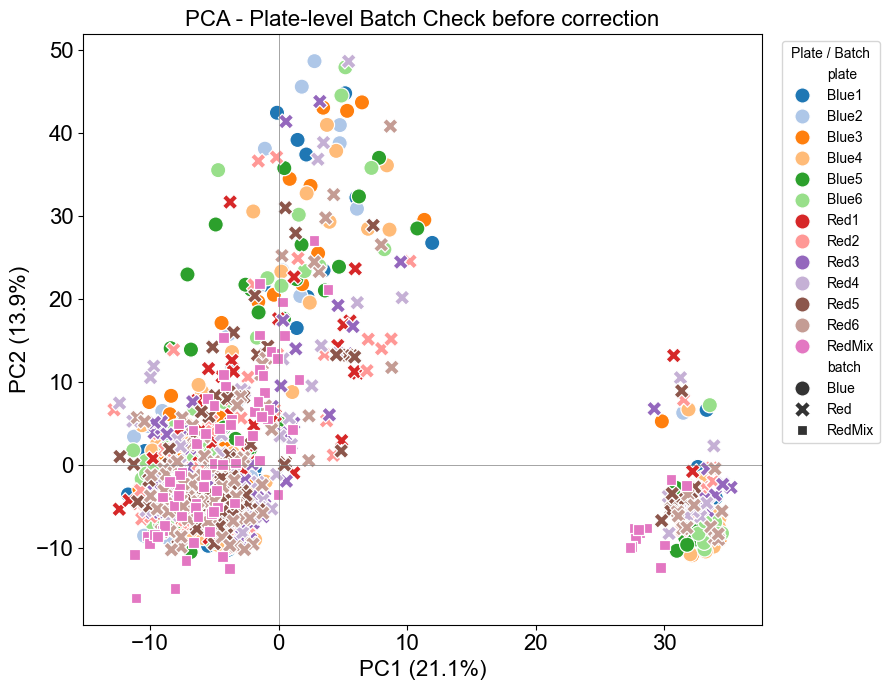

In [59]:

# =========================
# 2. PCA
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.T)   # 样本在行

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "sample": samples,
    "batch": batch_list,   # Red / Blue / RedMix
    "plate": plate_list    # Blue1 / Blue2 / Red1 / Red2 ...
})

# =========================
# 3. 画 PCA 图：颜色 = plate，形状 = batch
# =========================
plt.rcParams["font.family"] = "Arial" 
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="plate",      # Blue1, Blue2, Red1, Red2 各自一组颜色
    style="batch",    # Blue / Red / RedMix 不同 marker
    s=120,
    palette="tab20"   # 多组颜色
)

plt.title("PCA - Plate-level Batch Check before correction", fontsize = 16)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize = 16) 
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)
plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Plate / Batch")
plt.tight_layout()
# plt.savefig(f'{figure_path}\PCA_Plate level Batch Check before correction.svg', dpi=800)
plt.show()


In [ ]:
df_norm_loess

In [39]:
# # rename the columns to drug names 
# df_imputed_drugnames_replaced = df_imputed.rename(columns = map_well_to_drug)
# # df_imputed_drugnames_replaced

df_norm_loess_wellnames

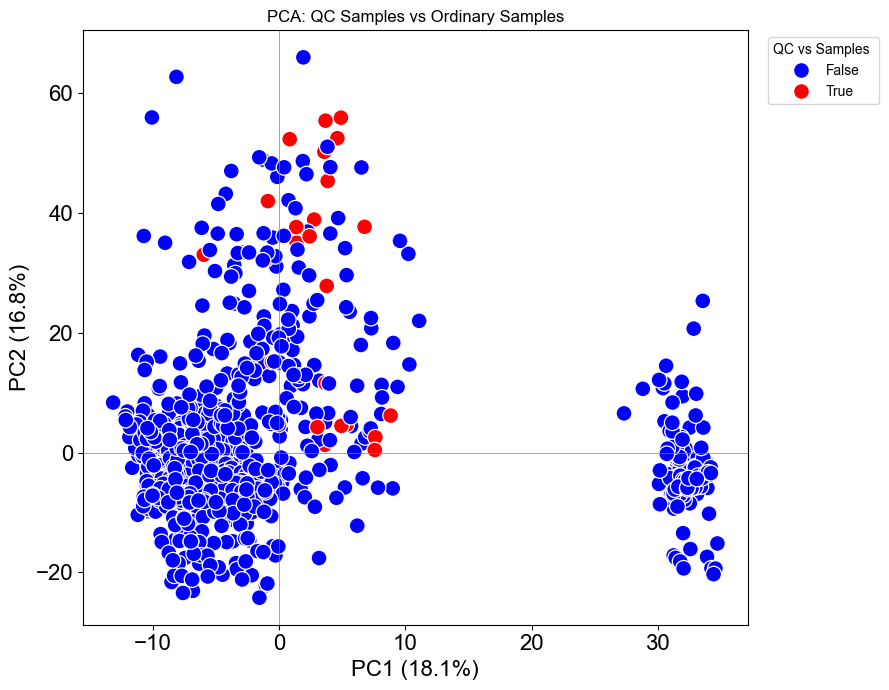

In [42]:

# ================================
# 0. 开始：你的矩阵（imputed 后）
# ================================
df2 = df_norm_loess.copy()   # <—— 按你的要求，从这里开始
samples2 = df2.columns

# =================================
# 1. 识别 QC 与 plate batch
# =================================

# QC：名称中包含 "_QC"（不区分大小写）
is_QC = samples2.str.contains("_DFO", case=False)


# =================================
# 2. PCA
# =================================
pca = PCA(n_components=2)
X = pca.fit_transform(df2.T)   # 样本作为行输入 PCA

pca_df2 = pd.DataFrame({
    "PC1": X[:,0],
    "PC2": X[:,1],
    "sample": samples2,
    "is_QC": is_QC,
})

# =================================
# 3. 绘图：QC vs Sample
# =================================
plt.figure(figsize=(9,7))
sns.scatterplot(
    data=pca_df2,
    x="PC1", y="PC2",
    hue="is_QC",     # QC / 非 QC 用不同颜色
    s=130,
    palette={True: "red", False: "blue"}  # QC=红色，普通样本=蓝色
)

plt.title("PCA: QC Samples vs Ordinary Samples")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize = 16) 
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="QC vs Samples ")
plt.tight_layout()
# plt.savefig(f'{figure_path}\PCA_QC VS samples before correction.svg', dpi=800)
plt.show()


In [ ]:
# Batch effect correction 

In [44]:
df_norm_loess_wellnames

,Blue1_B1,Blue1_C2,Blue1_C3,Blue1_C8,Blue1_E10,Blue1_H1,Blue1_E9,Blue1_D7,Blue1_B4,Blue1_A1,...,Redmix_D2,Redmix_D10,Redmix_B6,Redmix_C10,Redmix_G7,Redmix_A2,Redmix_E9,Redmix_B11,Redmix_F11,Redmix_C7
protein,,,,,,,,,,,,,,,,,,,,,
SMIM26,19.977340,19.302012,19.604277,19.869702,19.610779,17.521461,18.696323,18.359066,19.450061,18.070616,...,19.916016,18.785901,18.473830,18.819859,17.617753,19.583601,19.311905,18.807174,18.860206,19.142688
MSANTD7,13.418656,12.516715,14.281784,12.998894,13.811855,13.189003,13.311263,14.125644,14.417326,14.200878,...,14.314633,13.348875,14.123654,14.719314,13.090876,14.232868,14.425550,13.006700,13.902602,13.647445
CAST,24.196157,24.294922,24.272726,24.270205,24.153999,25.045135,24.215227,24.056483,24.296267,24.150506,...,24.284664,24.023157,23.984407,24.054301,24.159613,24.085600,23.946959,23.878652,23.964471,24.005436
GNG5B,17.620371,17.433058,16.378344,17.469399,16.995204,19.270898,18.786739,17.328120,17.223316,18.595006,...,17.085268,16.619524,16.295840,17.218136,16.960974,15.776579,16.467434,16.325515,15.722912,16.880130
NKRF,22.130976,22.251732,22.185558,22.198947,22.165481,22.451116,22.229371,22.409892,22.115271,21.755319,...,21.988951,22.159334,22.052977,22.251018,21.827649,21.821147,21.936467,21.894440,22.004187,22.022160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FAM169A,24.437691,24.232360,23.981081,24.128569,24.014511,24.695118,24.492445,24.778942,24.413748,24.346181,...,24.190580,23.852800,23.997761,23.857992,24.148358,24.223264,23.745261,23.833461,23.837063,23.868587
ZHX2,20.774057,20.822379,20.826403,20.677165,20.835622,21.483516,19.954590,20.567783,20.617298,21.111034,...,20.666508,20.306121,20.701575,20.191041,21.237028,20.682183,20.601436,20.677932,20.742784,20.543279
MORC2,22.077501,22.218468,22.119446,22.029584,21.934104,22.431208,22.121517,22.437368,21.864872,22.235907,...,21.853098,21.672467,21.857091,21.635469,22.127593,21.694214,21.761948,21.810523,21.858532,21.835899


# batch effect correction 

In [60]:
import pandas as pd
import numpy as np

df = df_norm_loess_wellnames.copy()

# ===== 1. 从列名提取 plate / batch 信息 =====
def extract_batch(col):
    # 只取第一个 "_" 前面的部分，比如 Blue1_A1 -> Blue1
    return col.split("_")[0]

batches = [extract_batch(c) for c in df.columns]

# ===== 2. 标记 QC 样本（方案 B 会用到）=====
def is_qc_sample(col):
    return 1 if "QC" in col.upper() else 0

qc_flags = [is_qc_sample(c) for c in df.columns]


In [61]:
from neuroCombat import neuroCombat

# 构建 covars，只包含 batch 一列
covars_A = pd.DataFrame({
    "batch": batches
}, index=df.columns)   # index 对应样本（= df 的列）

# 调用 neuroCombat
combat_res_A = neuroCombat(
    dat=df.values,      # shape: features x samples（蛋白 x 样本）
    covars=covars_A,    # DataFrame，行 = 样本
    batch_col="batch"   # 告诉它 batch 信息在哪一列
    # categorical_cols 与 continuous_cols 可以不写
)

# 取出校正后的矩阵
data_combat_A = combat_res_A["data"]

df_combat_A = pd.DataFrame(
    data_combat_A,
    index=df.index,
    columns=df.columns
)

print("Before:", df.shape, " After A:", df_combat_A.shape)


[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
Before: (7882, 1210)  After A: (7882, 1210)


In [63]:
df_combat_A.rename(columns = map_well_to_drug)

,Caroverine (hydrochloride)_1,Tucatinib_1,Chloroprocaine (hydrochloride)_1,Liarozole_1,Aniracetam_1,Blue1_H1_DFO,Digitoxin_1,Clomiphene (citrate)_1,Betamethasone disodium phosphate_1,Blue1_A1_QC,...,Liranaftate_4,Cabazitaxel_4,Azelastine (hydrochloride)_2,Cabazitaxel_3,Redmix_G7_QC,Liranaftate_1,Paritaprevir_5,Latrepirdine (dihydrochloride)_2,Latrepirdine (dihydrochloride)_6,Cobicistat_3
protein,,,,,,,,,,,,,,,,,,,,,
SMIM26,19.954336,19.286872,19.585617,19.847952,19.592044,17.527056,18.688237,18.354907,19.433197,18.069817,...,20.492828,19.267270,18.928843,19.304096,18.000466,20.132340,19.837697,19.290340,19.347850,19.654190
MSANTD7,13.518288,12.630853,14.367534,13.105278,13.905163,13.292329,13.412622,14.213905,14.500895,14.287929,...,14.304816,13.530604,14.151715,14.629234,13.323775,14.239268,14.393734,13.256294,13.974506,13.769956
CAST,24.184537,24.271438,24.251909,24.249690,24.147444,24.931531,24.201317,24.061642,24.272622,24.144370,...,24.431787,24.115966,24.069168,24.153579,24.280764,24.191378,24.023942,23.941449,24.045092,24.094565
GNG5B,17.333492,17.172665,16.267089,17.203868,16.796725,18.750632,18.334934,17.082565,16.992581,18.170312,...,17.460941,17.026562,16.724675,17.584862,17.345018,16.240383,16.884714,16.752352,16.190330,17.269618
NKRF,22.105907,22.224042,22.159304,22.172403,22.139663,22.419100,22.202166,22.378770,22.090542,21.738399,...,22.029897,22.178603,22.085778,22.258622,21.889117,21.883443,21.984090,21.947411,22.043195,22.058881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FAM169A,24.410758,24.193281,23.927136,24.083349,23.962544,24.683415,24.468752,24.772198,24.385399,24.313835,...,24.264558,23.845745,24.025482,23.852181,24.212208,24.305083,23.712407,23.821766,23.826232,23.865319
ZHX2,20.749358,20.799479,20.803653,20.648855,20.813216,21.485251,19.899358,20.535398,20.586758,21.098890,...,20.719050,20.335571,20.756364,20.213117,21.326126,20.735730,20.649809,20.731207,20.800214,20.587926
MORC2,22.042383,22.175184,22.081898,21.997242,21.907293,22.375601,22.083849,22.381404,21.842071,22.191613,...,21.899582,21.714406,21.903676,21.676477,22.180984,21.736700,21.806139,21.855936,21.905152,21.881950


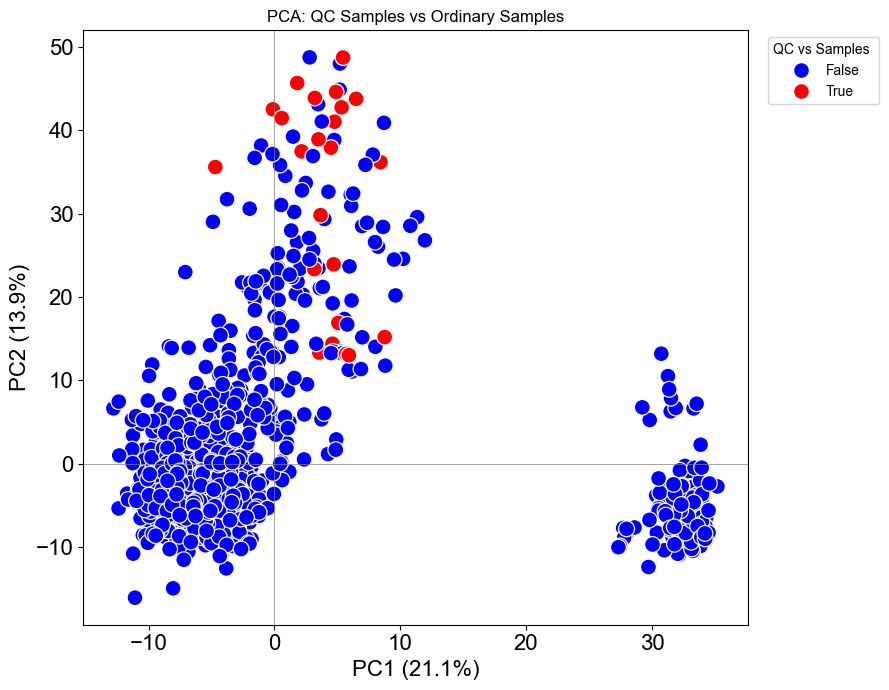

In [67]:

# ================================
# 0. 开始：你的矩阵（imputed 后）
# ================================
df2 = df_combat_A.rename(columns = map_well_to_drug) # <—— 按你的要求，从这里开始
samples2 = df2.columns

# =================================
# 1. 识别 QC 与 plate batch
# =================================

# QC：名称中包含 "_QC"（不区分大小写）
is_QC = samples2.str.contains("_DFO", case=False)


# =================================
# 2. PCA
# =================================
pca = PCA(n_components=2)
X = pca.fit_transform(df2.T)   # 样本作为行输入 PCA

pca_df2 = pd.DataFrame({
    "PC1": X[:,0],
    "PC2": X[:,1],
    "sample": samples2,
    "is_QC": is_QC,
})

# =================================
# 3. 绘图：QC vs Sample
# =================================
plt.figure(figsize=(9,7))
sns.scatterplot(
    data=pca_df2,
    x="PC1", y="PC2",
    hue="is_QC",     # QC / 非 QC 用不同颜色
    s=130,
    palette={True: "red", False: "blue"}  # QC=红色，普通样本=蓝色
)

plt.title("PCA: QC Samples vs Ordinary Samples")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize = 16) 
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize = 16)
plt.xticks(fontsize = 16)
plt.yticks(fontsize = 16)

plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="QC vs Samples ")
plt.tight_layout()
# plt.savefig(f'{figure_path}\PCA_QC VS samples before correction.svg', dpi=800)
plt.show()

In [69]:
# df_combat_A.rename(columns = map_well_to_drug).to_csv(f'{file_path}\log_imputed_normalized_OrderedByTime_BatchCorrected_drugnames.csv')